In [14]:
import pandas as pd
import numpy as np
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

data = pd.read_csv("dataset/banknote-authentication.csv", index_col="id")
# data = pd.read_csv("dataset/magic-gamma-telescope.csv", index_col="id")
# data = pd.read_csv("dataset/mass.csv")
# data = pd.read_csv("dataset/onehr.csv", index_col="Date")
# data = pd.read_csv("dataset/eighthr.csv", index_col="Date")

data.head()

,N,N_1,N_2,N_3,target
id,,,,,
id_1,3.62160,8.6661,-2.8073,-0.44699,0
id_2,4.54590,8.1674,-2.4586,-1.46210,0
id_3,3.86600,-2.6383,1.9242,0.10645,0
id_4,3.45660,9.5228,-4.0112,-3.59440,0
id_5,0.32924,-4.4552,4.5718,-0.98880,0


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1372 entries, id_1 to id_1372
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       1372 non-null   float64
 1   N_1     1372 non-null   float64
 2   N_2     1372 non-null   float64
 3   N_3     1372 non-null   float64
 4   target  1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.3+ KB


In [16]:
data.replace("?", np.nan, inplace=True)

for i in data.columns[:-1]:
    data[i] = data[i].astype(str).astype(float)
    data[i] = data[i].fillna(data[i].mean())
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1372 entries, id_1 to id_1372
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       1372 non-null   float64
 1   N_1     1372 non-null   float64
 2   N_2     1372 non-null   float64
 3   N_3     1372 non-null   float64
 4   target  1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.3+ KB


In [17]:
seed = 426

X = data.drop(columns=["target"], axis=1).values
n, p = X.shape
y = data["target"].values
y_unique = data["target"].unique()
if y_unique[0] != 0 and y_unique[1] != 1:
    y = np.array([0 if element == y_unique[0] else 1 for element in y])

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.5, random_state=seed
)
valid_X, test_X, valid_y, test_y = train_test_split(
    test_X, test_y, test_size=0.25, random_state=seed
)
std = StandardScaler()
train_X = std.fit_transform(train_X)
valid_X = std.transform(valid_X)
test_X = std.transform(test_X)

<Axes: >

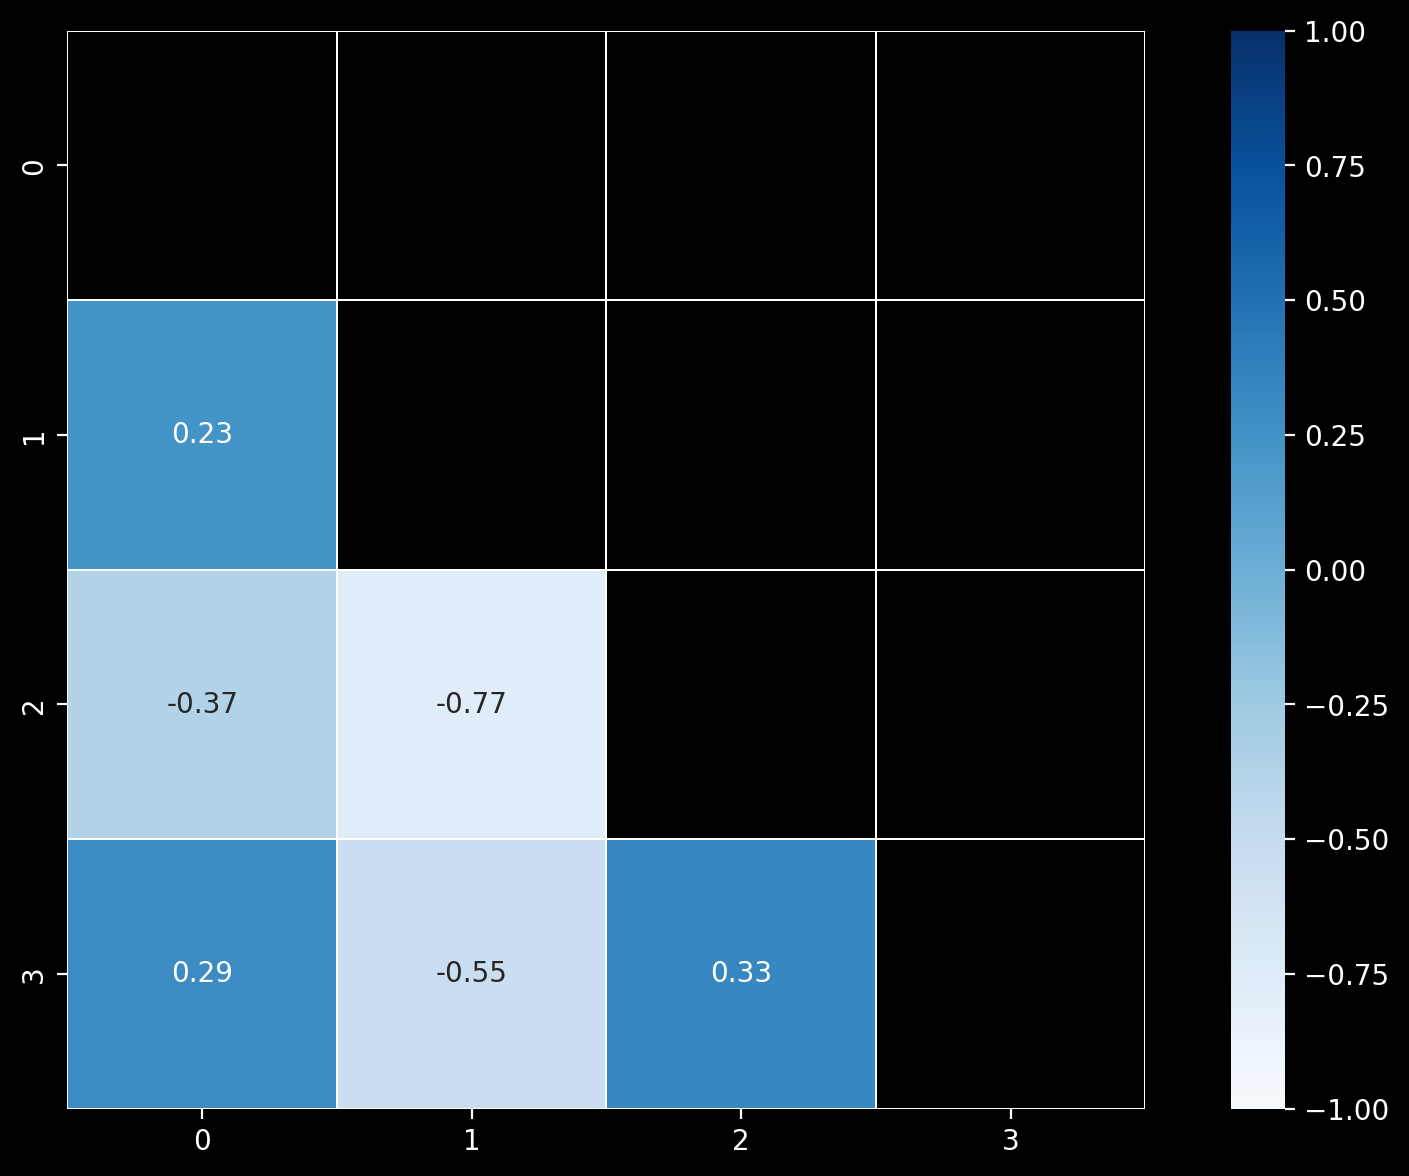

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.subplots(figsize=(11, 7), dpi=200)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(pd.DataFrame(train_X).corr(), dtype=bool))

# Draw the correlation heatmap with the mask
sns.heatmap(
    pd.DataFrame(train_X).corr(),
    vmax=1,
    vmin=-1,
    mask=mask,
    linewidths=0.1,
    annot=True,
    cmap="Blues",
    square=True,
)

# plt.title("Correlation ( )", size=12)
# plt.savefig("dataset/correlation_ .png")